# 🦠 COVID-19 Data Analysis & Prediction Project

This notebook analyzes COVID-19 data across Indian states/UTs. It is organized into the following sections:

1. **Import Libraries**
2. **Load Data**
3. **Data Cleaning & Preprocessing**
4. **Visualizations** (each with a different chart type)
5. **Exploratory Data Analysis (EDA)**
6. **Creativity – Risk Classification**
7. **Extra Creativity – Wave Detection**
8. **Machine Learning – Model Training**
9. **Prediction & Prediction Graph**

---
## Section 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Set plot style for better aesthetics
sns.set_theme(style="whitegrid")
print("✅ All libraries imported successfully.")

ModuleNotFoundError: No module named 'pandas'

---
## Section 2: Load Data

In [ ]:
df = pd.read_csv("complete.csv")

print("First 5 rows:")
display(df.head())
print("\nDataset Shape:", df.shape)

First 5 rows:


,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0



Dataset Shape: (4692, 10)


---
## Section 3: Data Cleaning & Preprocessing

In [ ]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Rename columns
df.rename(columns={
    'Name of State / UT': 'State',
    'Total Confirmed cases': 'Confirmed',
    'Cured/Discharged/Migrated': 'Recovered',
    'Death': 'Deaths'
}, inplace=True)

# Convert to numeric
df['Confirmed'] = pd.to_numeric(df['Confirmed'], errors='coerce')
df['Deaths'] = pd.to_numeric(df['Deaths'], errors='coerce')
df['Recovered'] = pd.to_numeric(df['Recovered'], errors='coerce')

# Remove duplicates & fill missing
df.drop_duplicates(inplace=True)
df.fillna(0, inplace=True)

print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
Date             datetime64[us]
State                       str
Latitude                float64
Longitude               float64
Confirmed               float64
Deaths                  float64
Recovered               float64
New cases                 int64
New deaths                int64
New recovered             int64
dtype: object

Missing Values:
Date             0
State            0
Latitude         0
Longitude        0
Confirmed        0
Deaths           0
Recovered        0
New cases        0
New deaths       0
New recovered    0
dtype: int64


---
## Section 4: Visualizations
Each sub-section uses a **different type of chart**.

### 4.1 COVID-19 Cases Trend Over Time — 📈 Line Chart

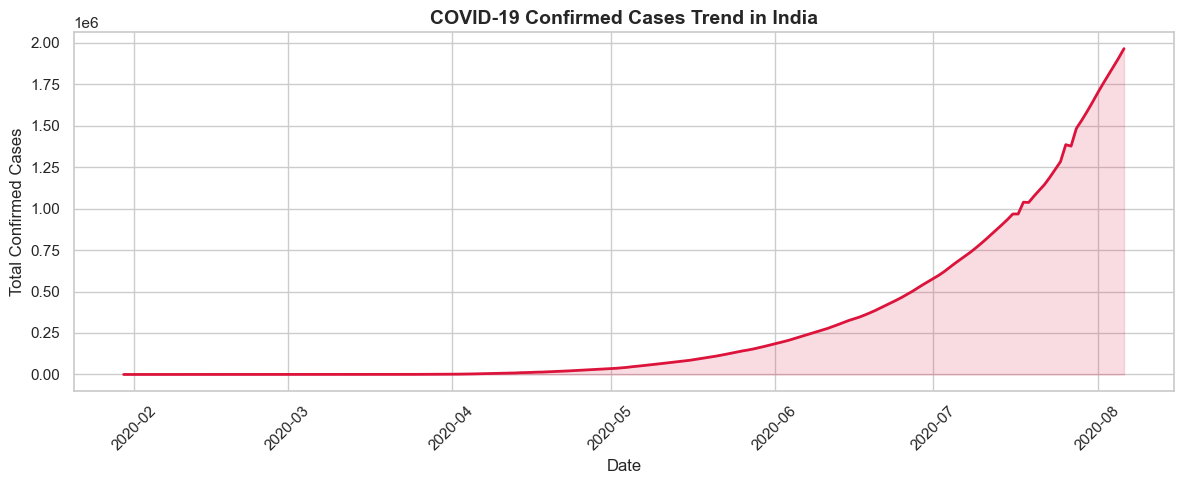

In [ ]:
daily = df.groupby('Date')['Confirmed'].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily.values, color='crimson', linewidth=2)
plt.fill_between(daily.index, daily.values, alpha=0.15, color='crimson')
plt.title("COVID-19 Confirmed Cases Trend in India", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Total Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2 Correlation Between Confirmed, Recovered & Deaths — 🔥 Heatmap

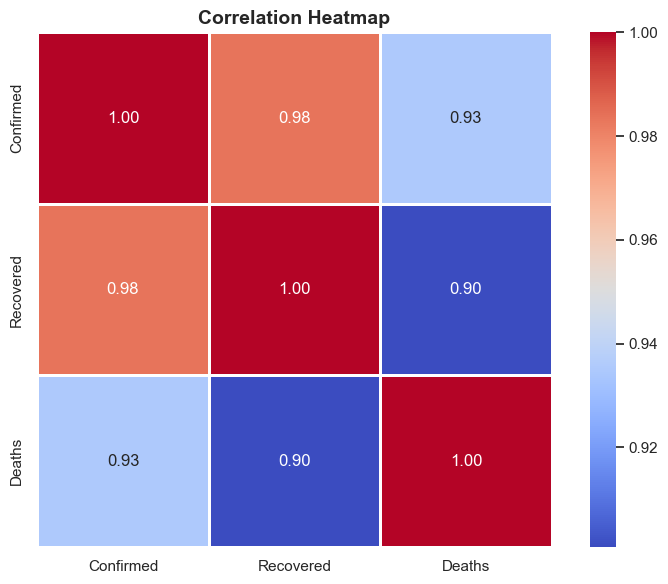

In [ ]:
plt.figure(figsize=(8, 6))
corr = df[['Confirmed', 'Recovered', 'Deaths']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, square=True)
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Top 5 Affected States — 📊 Horizontal Bar Chart

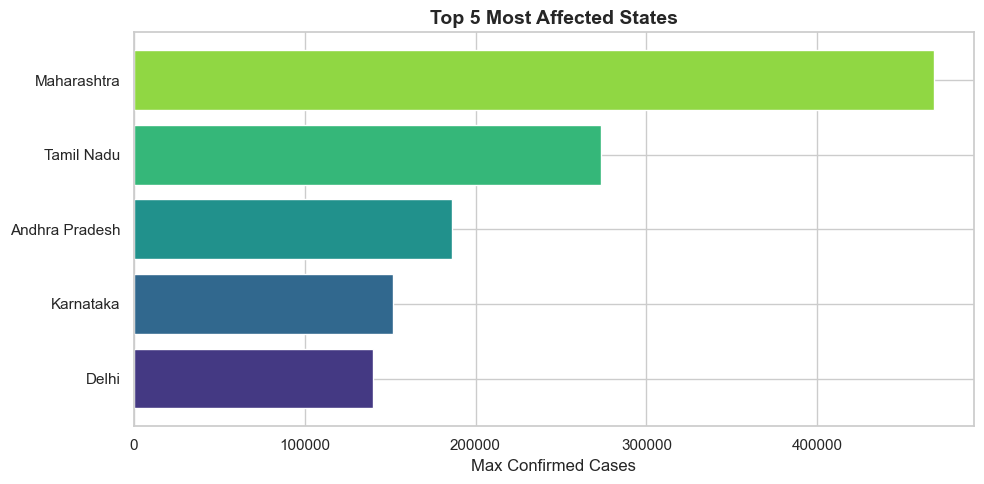

In [ ]:
top_states = df.groupby('State')['Confirmed'].max().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
colors = sns.color_palette('viridis', len(top_states))
plt.barh(top_states.index[::-1], top_states.values[::-1], color=colors)
plt.title("Top 5 Most Affected States", fontsize=14, fontweight='bold')
plt.xlabel("Max Confirmed Cases")
plt.tight_layout()
plt.show()

### 4.4 Confirmed vs Recovered vs Deaths Over Time — 📉 Stacked Area Chart

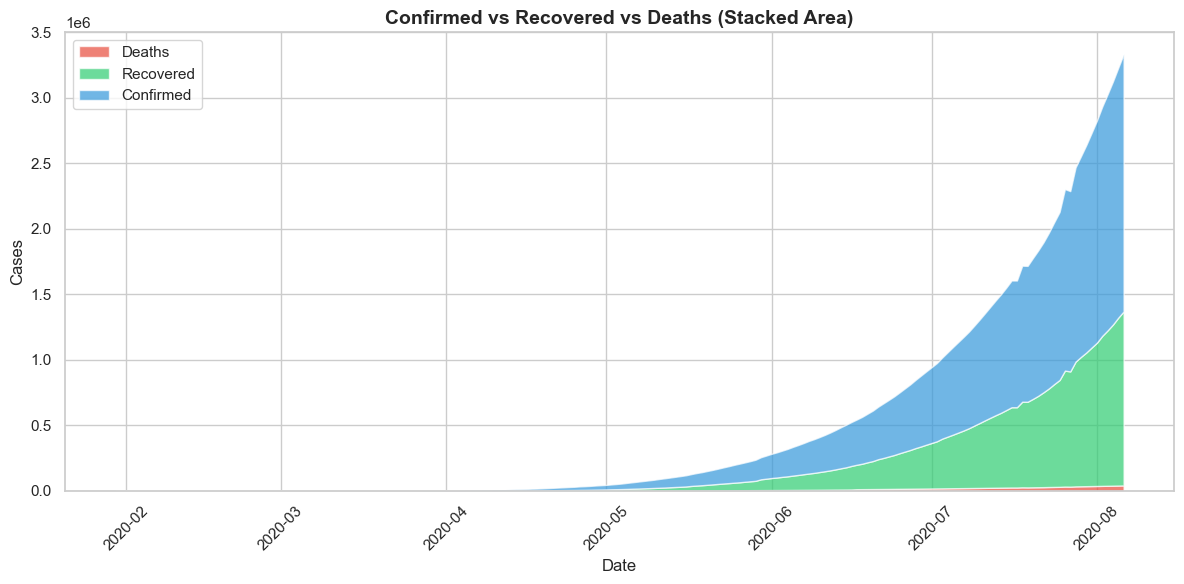

In [ ]:
time_data = df.groupby('Date')[['Confirmed', 'Recovered', 'Deaths']].sum()

plt.figure(figsize=(12, 6))
plt.stackplot(time_data.index, time_data['Deaths'], time_data['Recovered'], time_data['Confirmed'],
              labels=['Deaths', 'Recovered', 'Confirmed'],
              colors=['#e74c3c', '#2ecc71', '#3498db'], alpha=0.7)
plt.title("Confirmed vs Recovered vs Deaths (Stacked Area)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Section 5: Exploratory Data Analysis (EDA)

In [ ]:
print("Top 5 States by Confirmed Cases:")
print(top_states)

# Death rate
df['Death_Rate'] = df['Deaths'] / df['Confirmed'].replace(0, 1)
print("\nAverage Death Rate:", round(df['Death_Rate'].mean(), 4))

print("\nDescriptive Statistics:")
display(df[['Confirmed', 'Recovered', 'Deaths']].describe())

Top 5 States by Confirmed Cases:
State
Maharashtra       468265.0
Tamil Nadu        273460.0
Andhra Pradesh    186461.0
Karnataka         151449.0
Delhi             140232.0
Name: Confirmed, dtype: float64

Average Death Rate: 0.0169

Descriptive Statistics:


,Confirmed,Recovered,Deaths
count,4692.000000,4692.000000,4692.000000
mean,11393.925192,6908.130648,291.218670
std,37208.600846,23390.671258,1213.695272
min,1.000000,0.000000,0.000000
25%,39.000000,9.000000,0.000000
50%,619.000000,197.500000,5.000000
75%,5233.000000,2736.000000,68.250000
max,468265.000000,305521.000000,16476.000000


### 5.1 Death Rate Distribution — 📦 Box Plot

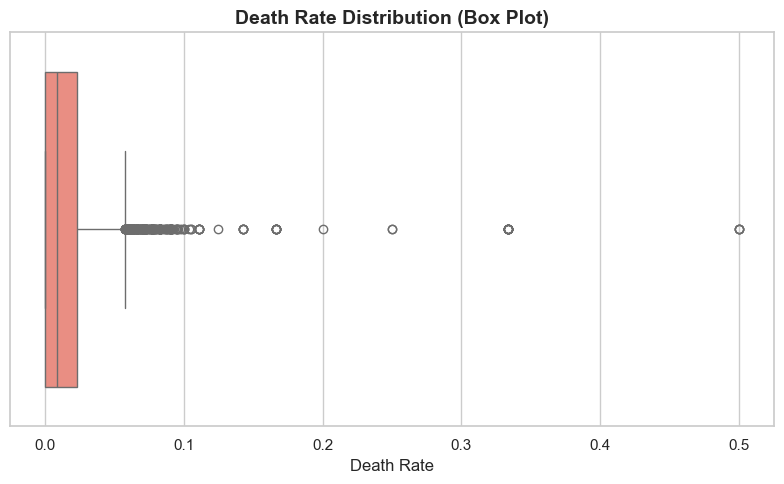

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Death_Rate', color='salmon')
plt.title("Death Rate Distribution (Box Plot)", fontsize=14, fontweight='bold')
plt.xlabel("Death Rate")
plt.tight_layout()
plt.show()

---
## Section 6: Creativity — Risk Classification

In [ ]:
def risk(row):
    if row['Confirmed'] > 50000:
        return "High"
    elif row['Confirmed'] > 10000:
        return "Medium"
    else:
        return "Low"

df['Risk_Level'] = df.apply(risk, axis=1)

print("Risk Classification Sample:")
display(df[['State', 'Confirmed', 'Risk_Level']].head(10))

Risk Classification Sample:


,State,Confirmed,Risk_Level
0,Kerala,1.0,Low
1,Kerala,1.0,Low
2,Kerala,2.0,Low
3,Kerala,3.0,Low
4,Kerala,3.0,Low
5,Kerala,3.0,Low
6,Kerala,3.0,Low
7,Kerala,3.0,Low
8,Kerala,3.0,Low
9,Kerala,3.0,Low


### 6.1 Risk Level Distribution — 🥧 Pie Chart

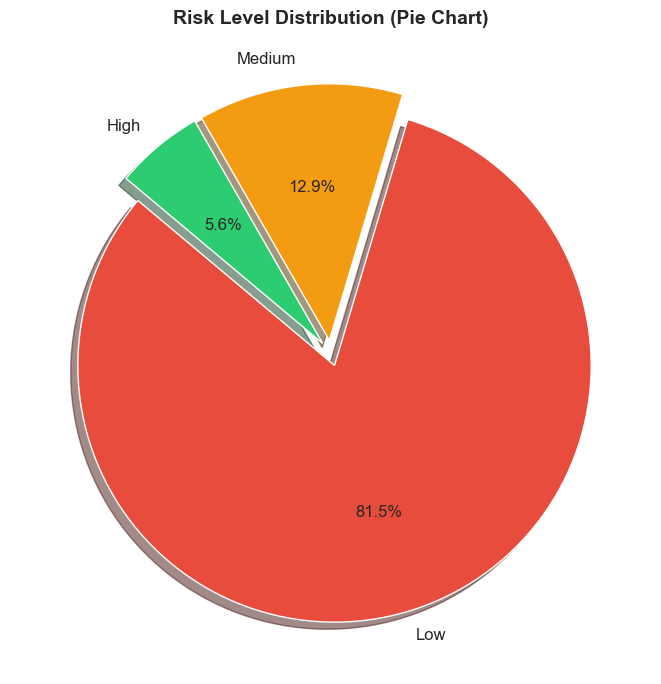

In [ ]:
risk_counts = df['Risk_Level'].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
explode = (0.05, 0.05, 0.05)
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
        colors=colors, explode=explode, startangle=140, shadow=True,
        textprops={'fontsize': 12})
plt.title("Risk Level Distribution (Pie Chart)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 7: Extra Creativity — Wave Detection

In [ ]:
daily_cases = df.groupby('Date')['Confirmed'].sum()
mean_val = daily_cases.mean()
peaks = daily_cases[daily_cases > mean_val]

print(f"Average daily cases: {mean_val:,.0f}")
print(f"\nNumber of peak days (above average): {len(peaks)}")
print("\nSample Peak Days:")
print(peaks.head(10))

Average daily cases: 287,421

Number of peak days (above average): 52

Sample Peak Days:
Date
2020-06-12    289220.0
2020-06-13    301009.0
2020-06-14    313486.0
2020-06-15    325452.0
2020-06-16    335407.0
2020-06-17    345792.0
2020-06-18    358243.0
2020-06-19    371605.0
2020-06-20    385783.0
2020-06-21    401334.0
Name: Confirmed, dtype: float64


### 7.1 Wave Detection — 📊 Bar Chart with Threshold Line

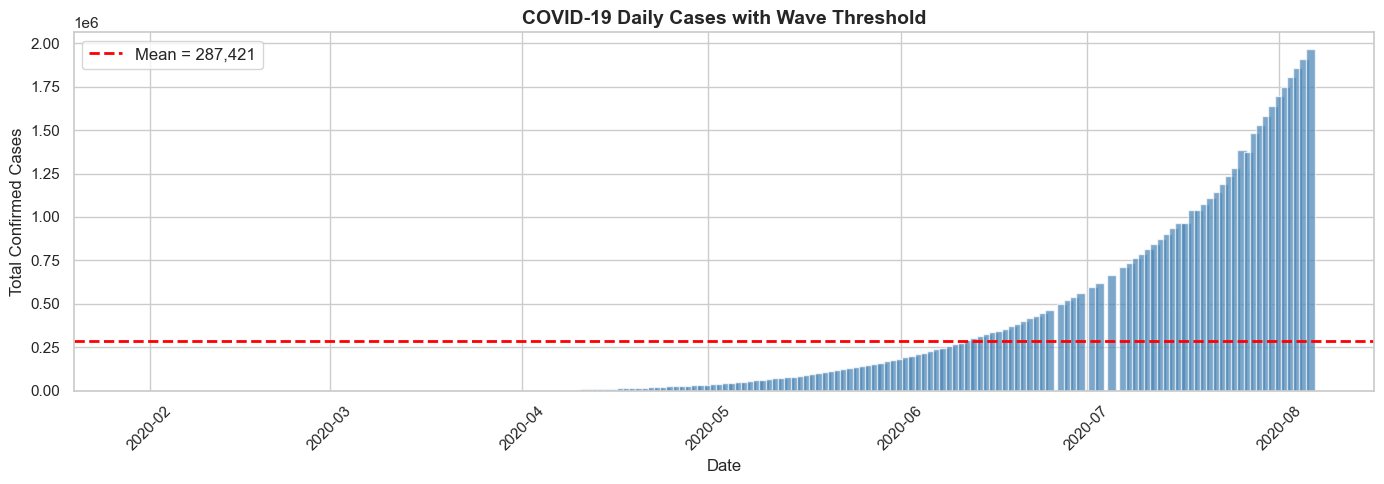

In [ ]:
plt.figure(figsize=(14, 5))
plt.bar(daily_cases.index, daily_cases.values, color='steelblue', width=1.5, alpha=0.7)
plt.axhline(y=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:,.0f}')
plt.title("COVID-19 Daily Cases with Wave Threshold", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Total Confirmed Cases")
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Section 8: Machine Learning — Model Training (Linear Regression)

In [ ]:
# Convert date to numeric (days since start)
df['Days'] = (df['Date'] - df['Date'].min()).dt.days

data = df.groupby('Days')['Confirmed'].sum().reset_index()

X = data[['Days']]
y = data['Confirmed']

# Train model
model = LinearRegression()
model.fit(X, y)

print("✅ Model trained successfully!")
print(f"   R² Score : {model.score(X, y):.4f}")
print(f"   Slope    : {model.coef_[0]:,.2f}")
print(f"   Intercept: {model.intercept_:,.2f}")

✅ Model trained successfully!
   R² Score : 0.6275
   Slope    : 6,874.01
   Intercept: -353,414.06


---
## Section 9: Prediction & Prediction Graph

In [ ]:
# Predict next 10 days
future = np.arange(max(X['Days']) + 1, max(X['Days']) + 11).reshape(-1, 1)
pred = model.predict(future)

print("Future Predictions (next 10 days):")
for day, cases in zip(future.flatten(), pred):
    print(f"   Day {day}: {int(cases):,} cases")

Future Predictions (next 10 days):
   Day 190: 952,647 cases
   Day 191: 959,521 cases
   Day 192: 966,395 cases
   Day 193: 973,269 cases
   Day 194: 980,143 cases
   Day 195: 987,017 cases
   Day 196: 993,891 cases
   Day 197: 1,000,765 cases
   Day 198: 1,007,639 cases
   Day 199: 1,014,513 cases


C:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### 9.1 Prediction Graph — 🔵 Scatter Plot + Regression Line

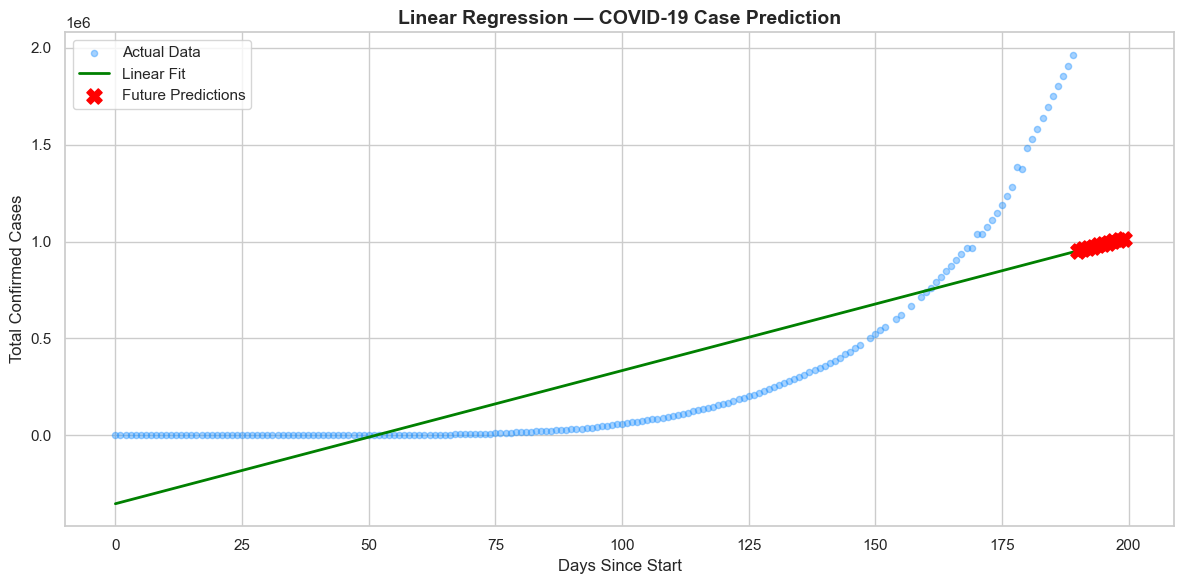

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='dodgerblue', alpha=0.4, s=20, label='Actual Data')
plt.plot(X, model.predict(X), color='green', linewidth=2, label='Linear Fit')
plt.scatter(future, pred, color='red', marker='X', s=120, zorder=5, label='Future Predictions')
plt.title("Linear Regression — COVID-19 Case Prediction", fontsize=14, fontweight='bold')
plt.xlabel("Days Since Start")
plt.ylabel("Total Confirmed Cases")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()